# Load Dataset

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

path = 'https://raw.githubusercontent.com/Sirinja/Dissertation/main/kidney_disease.csv?token=GHSAT0AAAAAACHMVE4VBHGG25QBWCGVVZ5AZH65DBA'

df = pd.read_csv(path)

# Exploratory Data Analysis (EDA)

In [3]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.shape

(400, 26)

In [5]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

We have identified that the columns 'pcv,' 'wc,' and 'rc' contain numeric data, even though their current data types indicate otherwise. We will proceed to convert their data types to numeric.

In [7]:
df[['pcv','wc','rc']] = df[['pcv','wc','rc']].apply(pd.to_numeric, errors='coerce', downcast='float')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             329 non-null    float32
 17  wc              294 non-null    flo

In [9]:
#pip install missingno

In [10]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


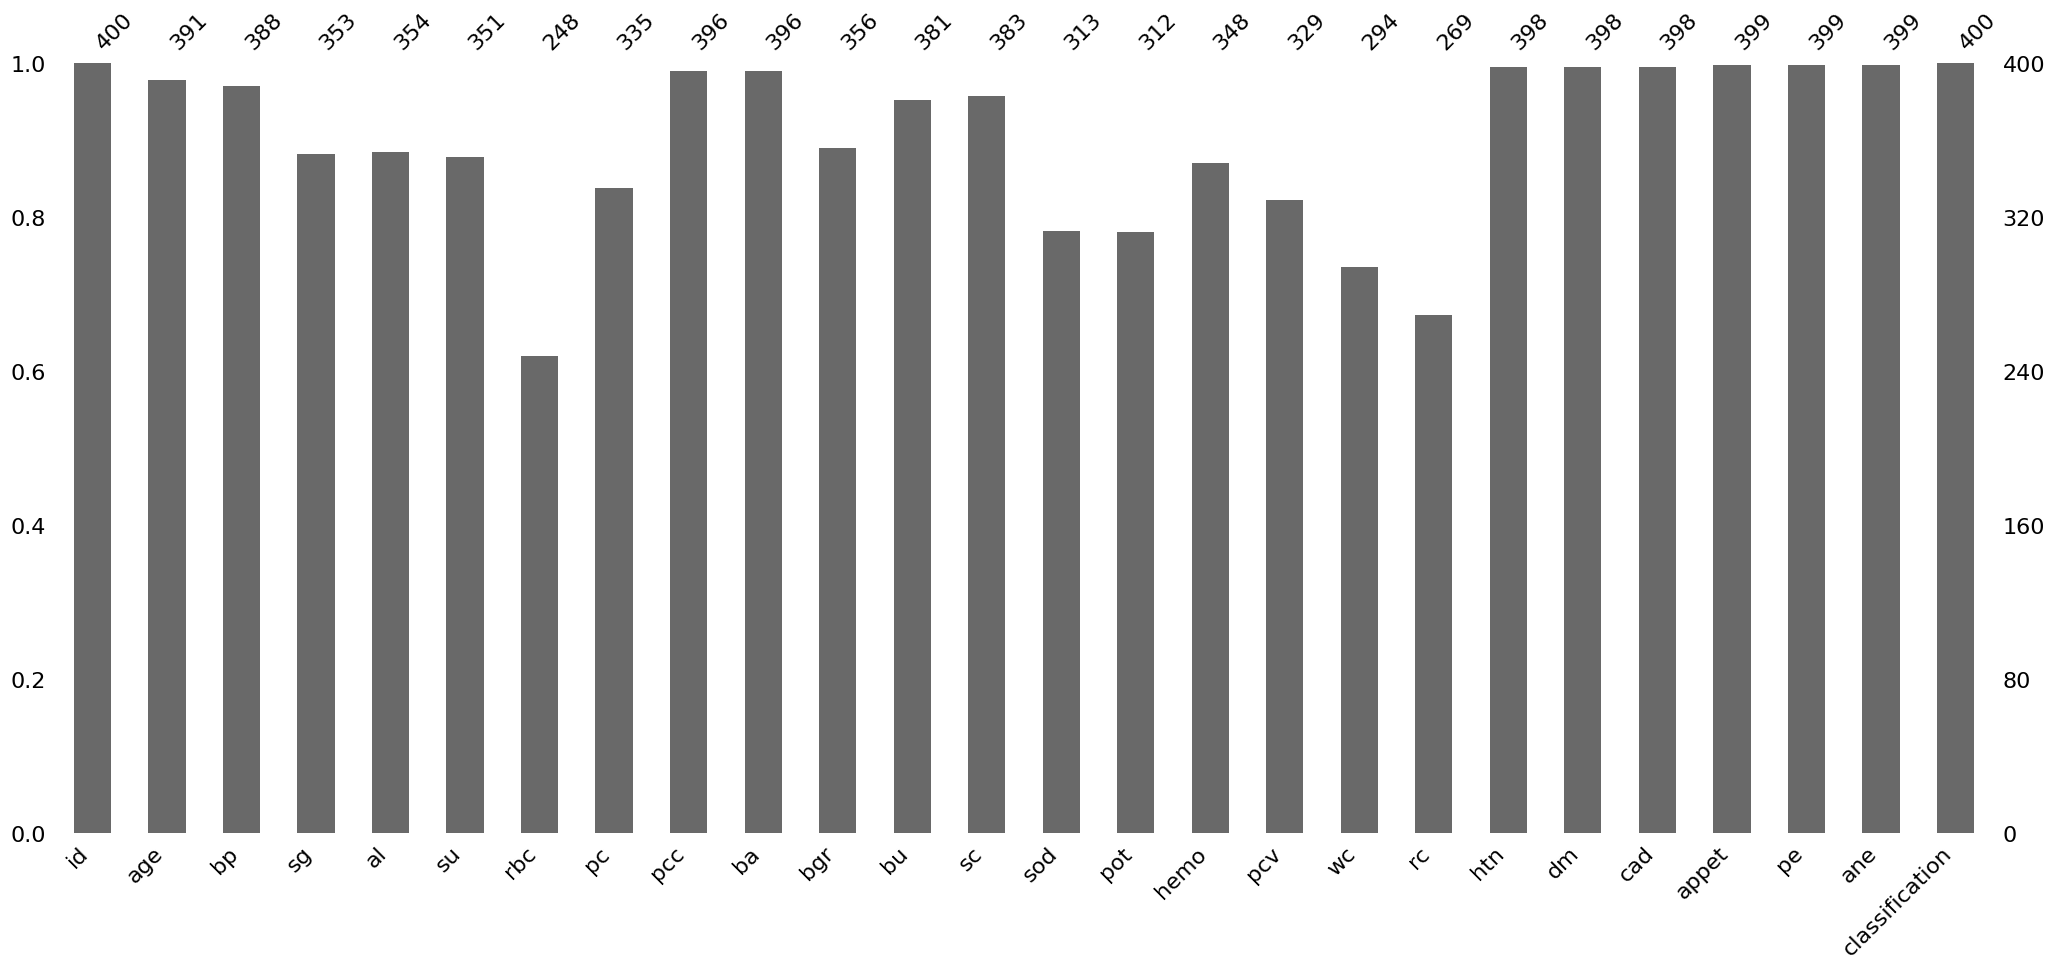

In [11]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df)

plt.savefig("missing value")
plt.show()

This dataset contains 400 observations, 25 features and target variable is classification.
There are 14 numerical features and 11 non-numerical features. There are missing values.

We will calculate the probability of target for finding class imbalance.

In [12]:
# Calculate the proportion of CKD patients
ckd_proportion = sum(df['classification'] != 'notckd')*100 / len(df)
print('Proportion of CKD patients:',sum(df['classification'] != 'notckd') ,', ',ckd_proportion,'%')

# Calculate the proportion of non-CKD patients
non_ckd_proportion = sum(df['classification'] == 'notckd')*100 / len(df)
print('Proportion of non-CKD patients:',sum(df['classification'] == 'notckd'),', ',non_ckd_proportion,'%')

Proportion of CKD patients: 250 ,  62.5 %
Proportion of non-CKD patients: 150 ,  37.5 %


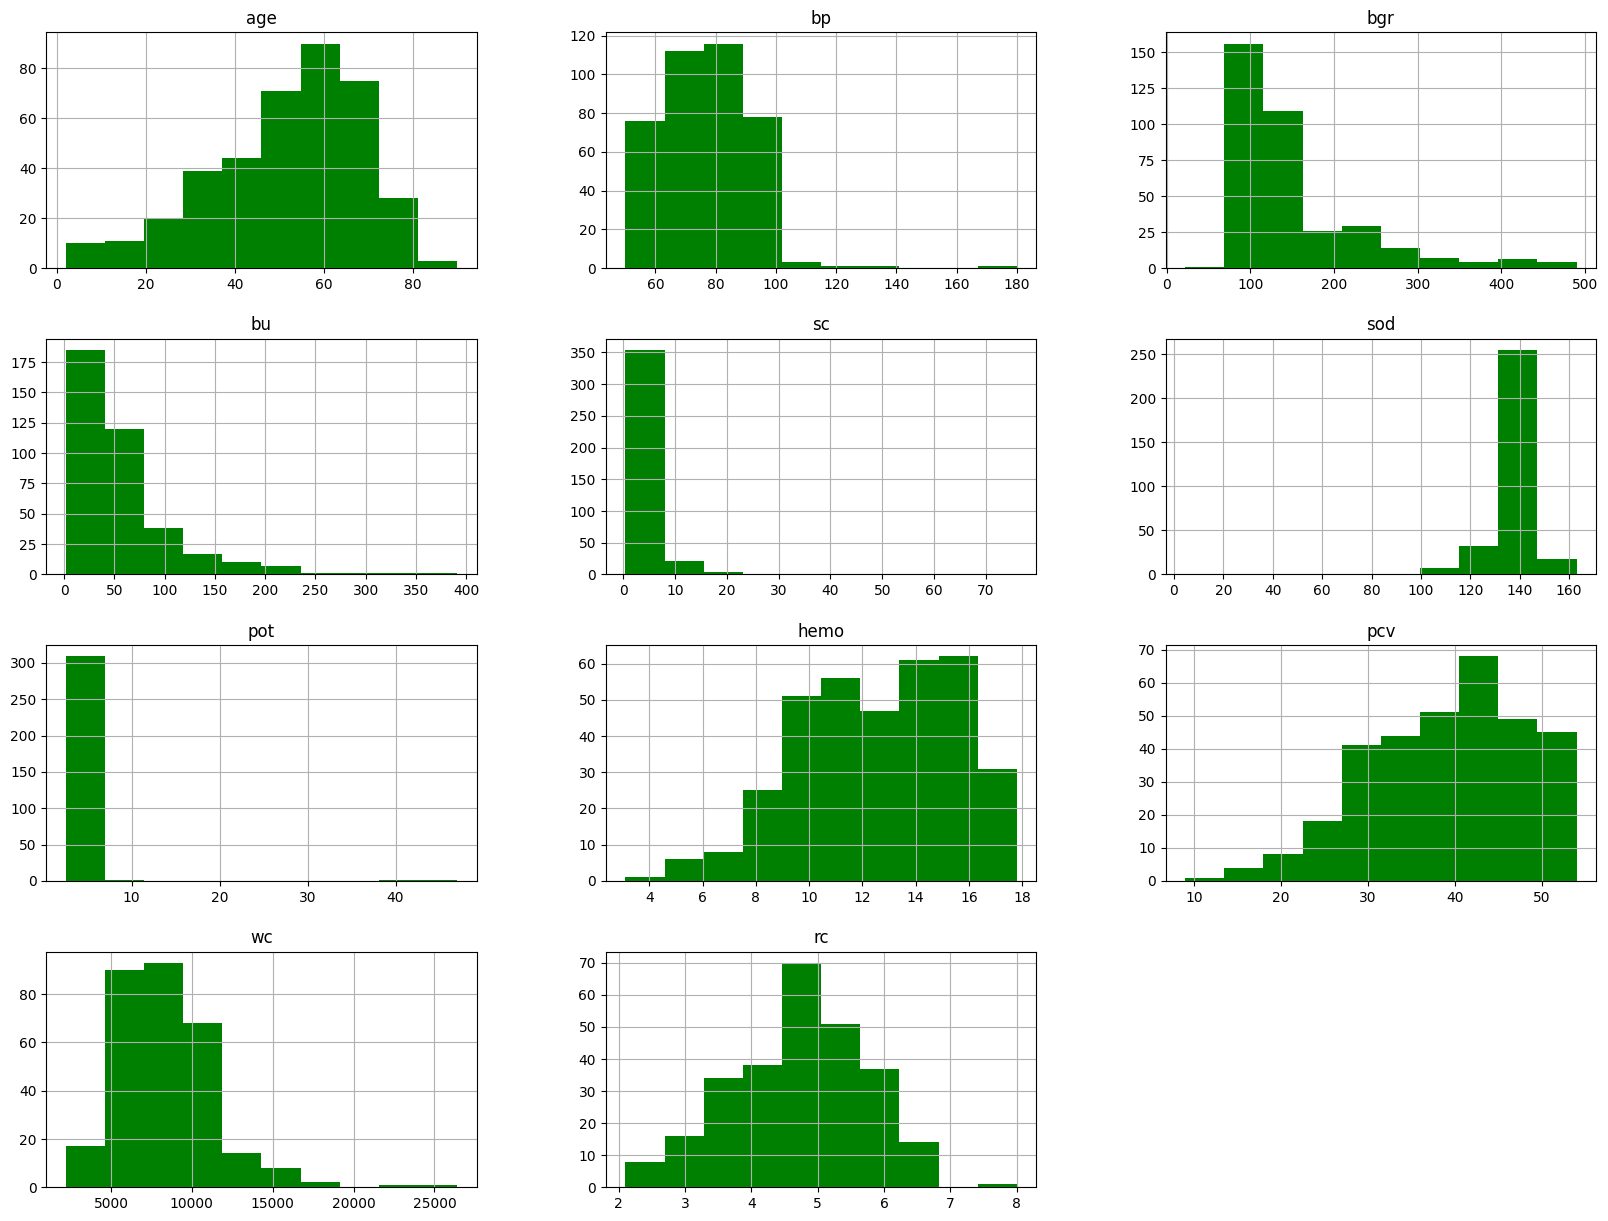

In [13]:
#Find the distribution of numerical features
#Create a histogram for numeric columns
df[['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']].hist(figsize=(20,15),color='green')
#Save the plot
_=plt.savefig('The distribution of numerical attributes.jpg')
# Display the plot
plt.show()

In [14]:
#plot bar graph for non-numeric variables
numeric_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']

def str_col(df, numeric_cols):
    lst = []
    for var in df.columns:
        if var not in numeric_cols:
            lst.append(var)
    return lst

string_cols = str_col(df, numeric_cols)[1:]

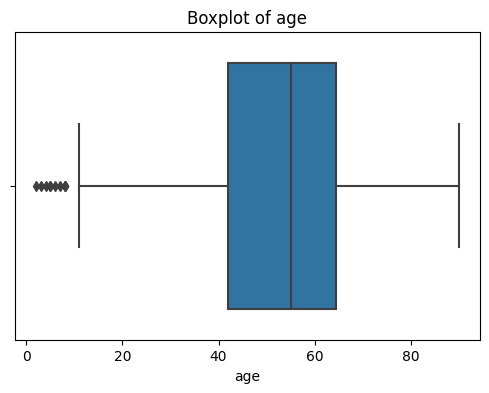

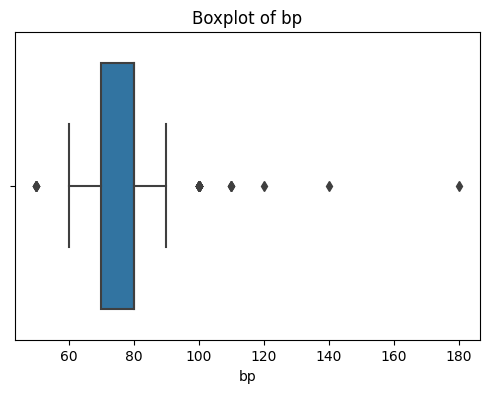

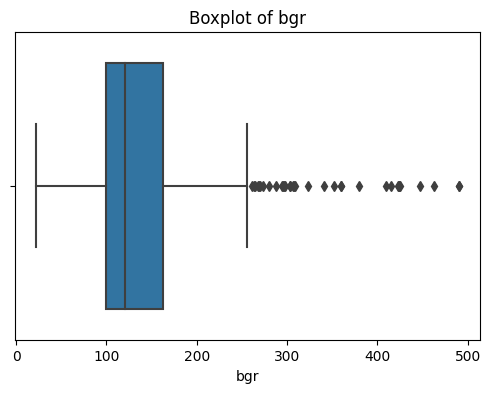

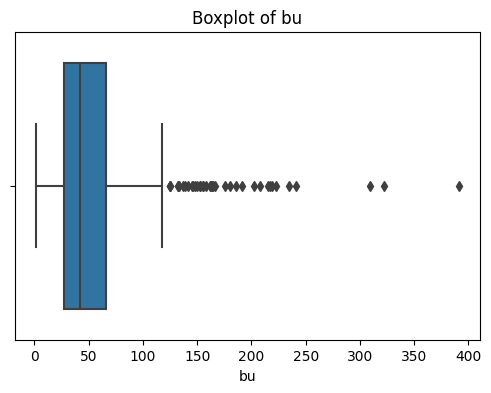

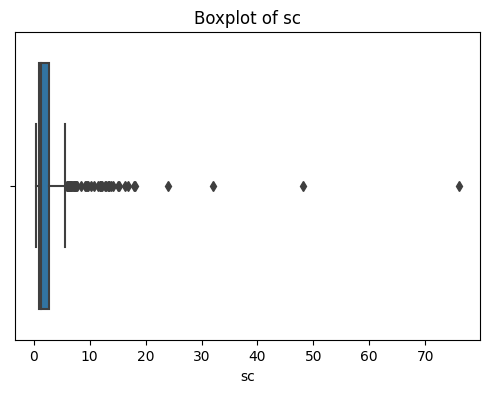

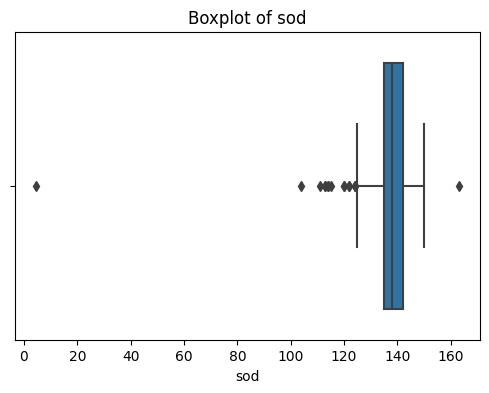

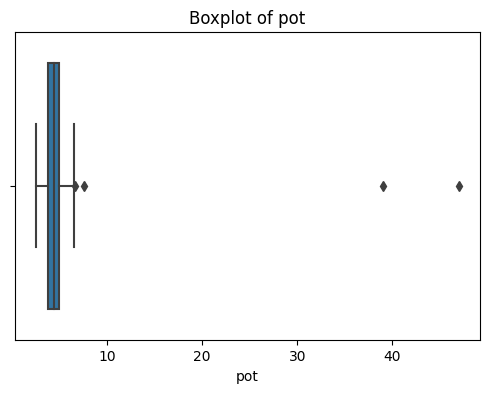

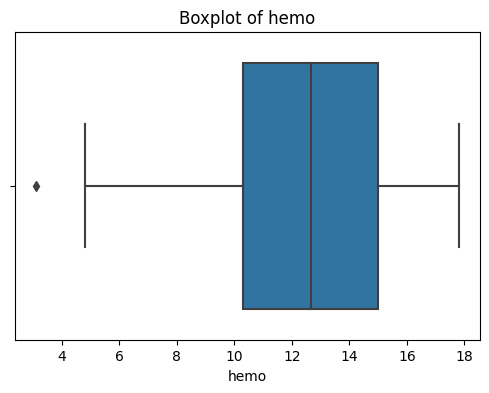

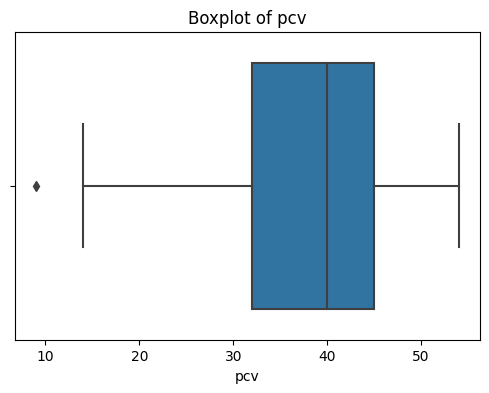

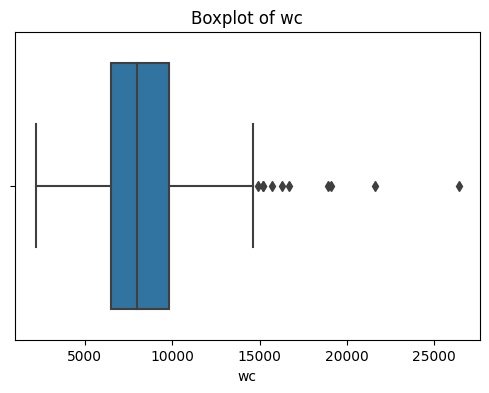

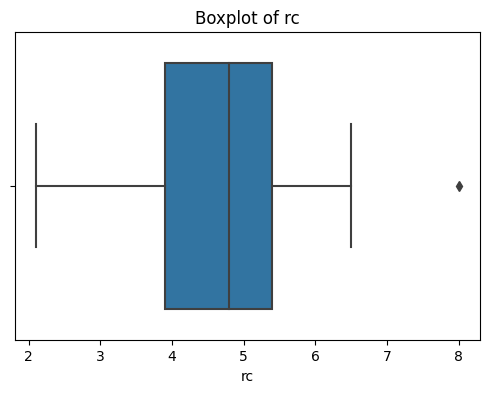

In [15]:
import seaborn as sns

for column in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=column)
    plt.xlabel(column)
    #plt.ylabel('Count')
    plt.title(f'Boxplot of {column}')

    # Save the figure as an image file (e.g., PNG)
    plt.savefig(f'{column}_boxplot.png')

    plt.show()

In [16]:
string_dict = {}

# Loop through the columns and store unique values in the dictionary
for col in string_cols:
    string_dict[col] = list(df[col].unique())

<Figure size 500x2000 with 0 Axes>

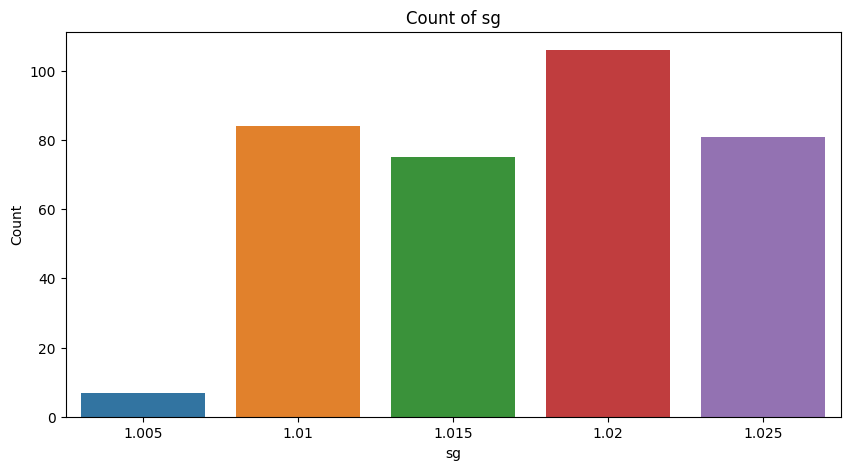

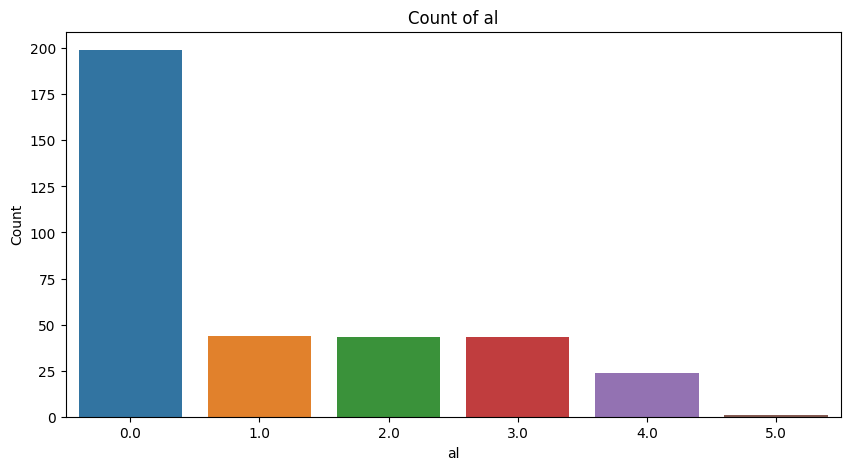

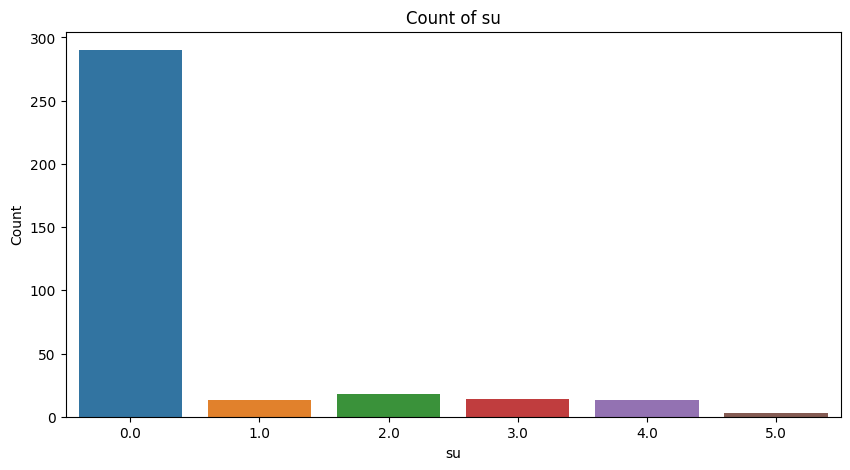

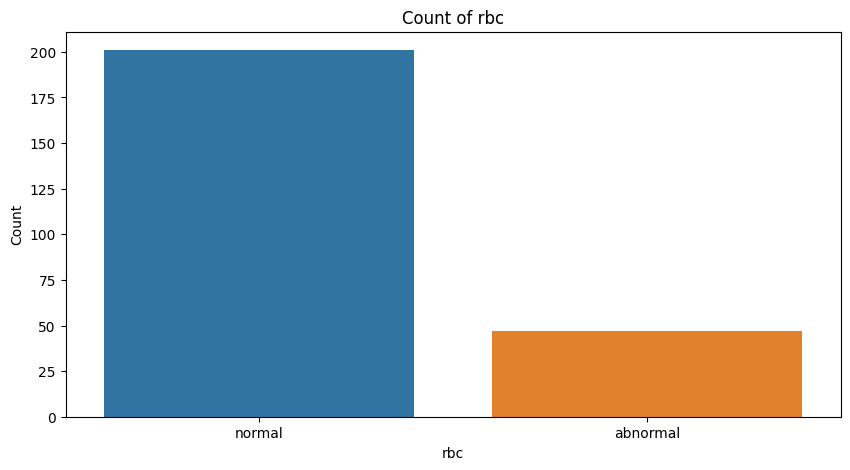

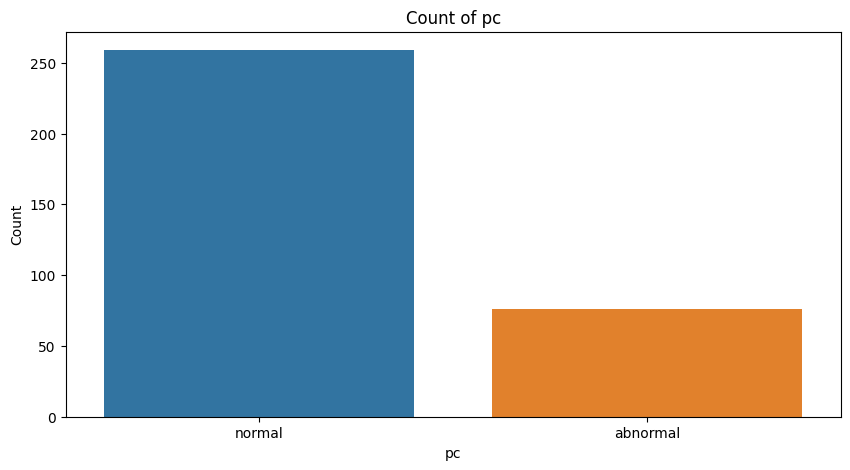

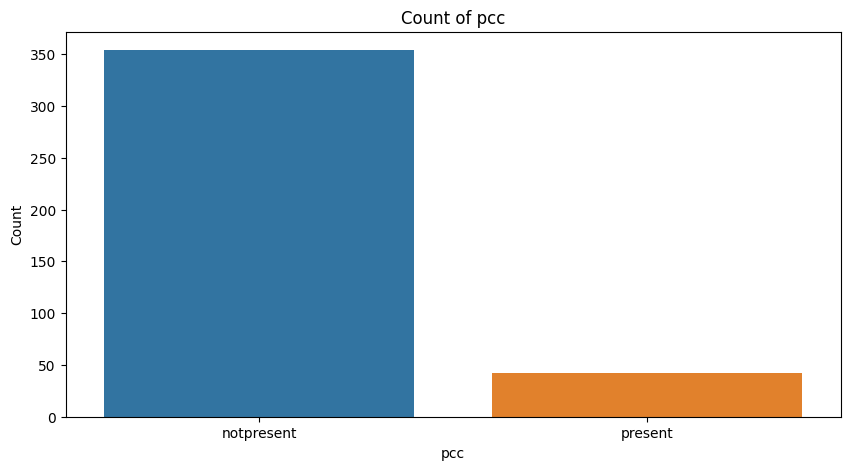

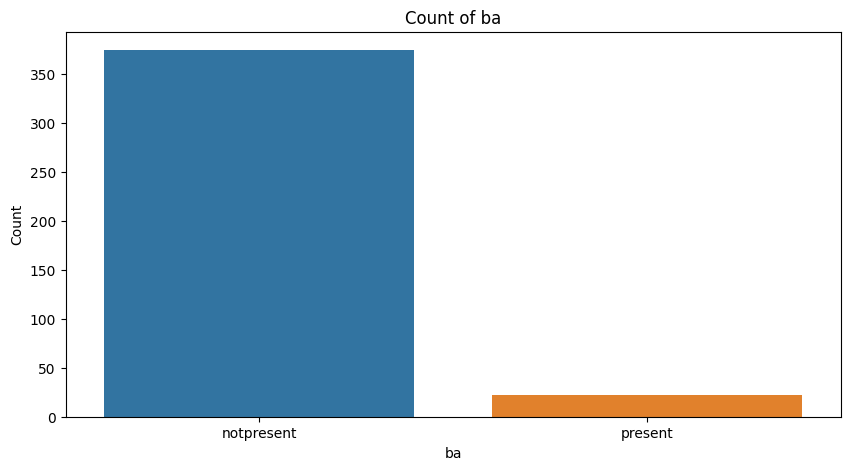

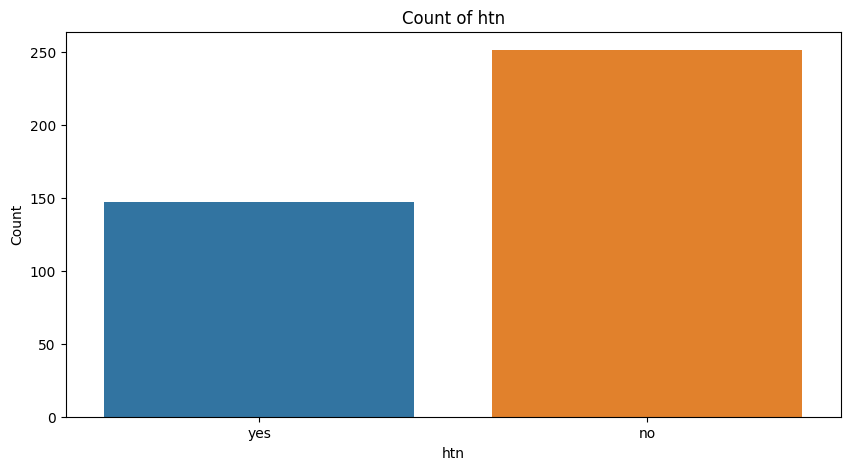

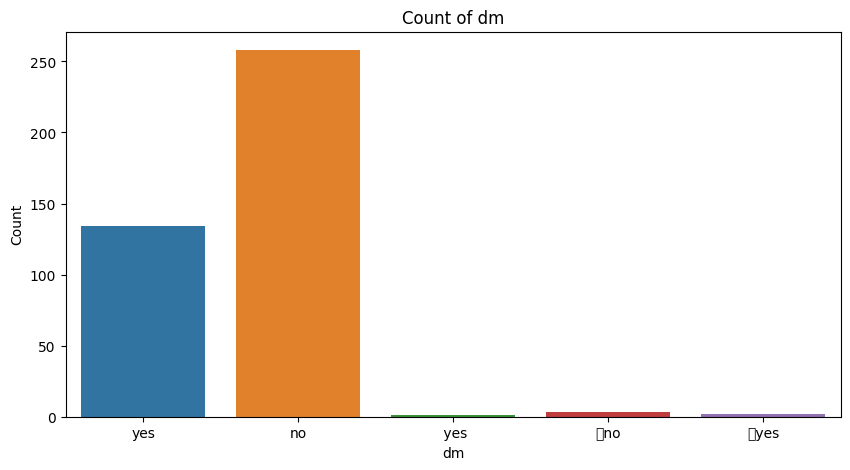

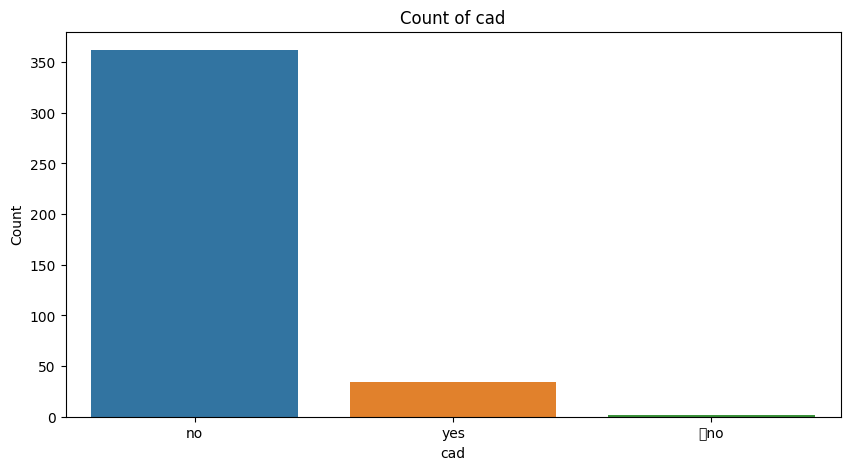

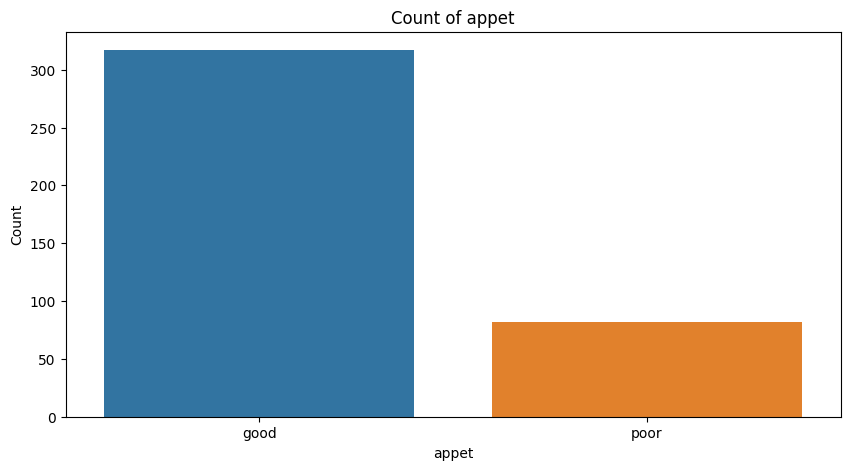

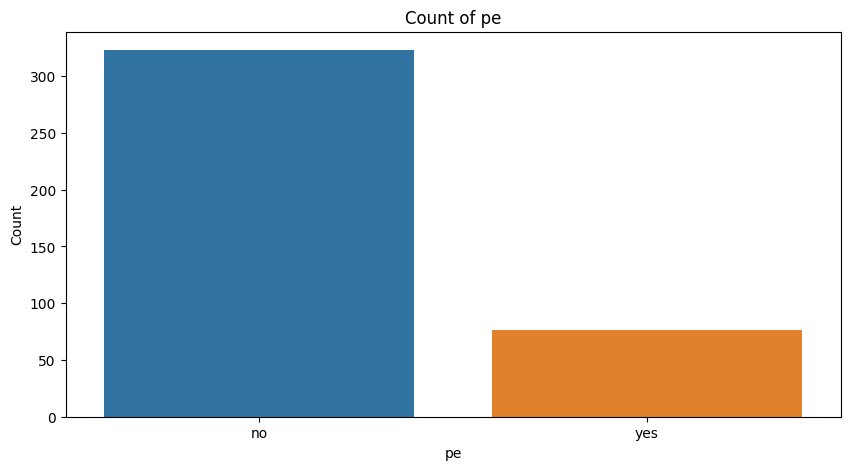

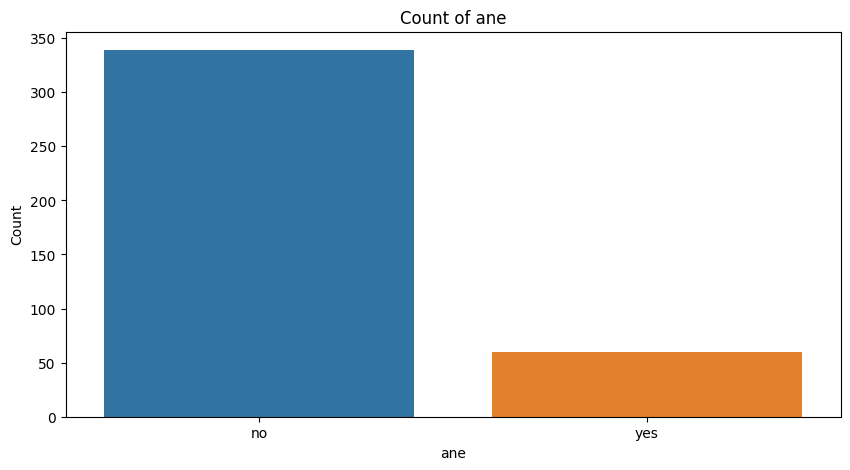

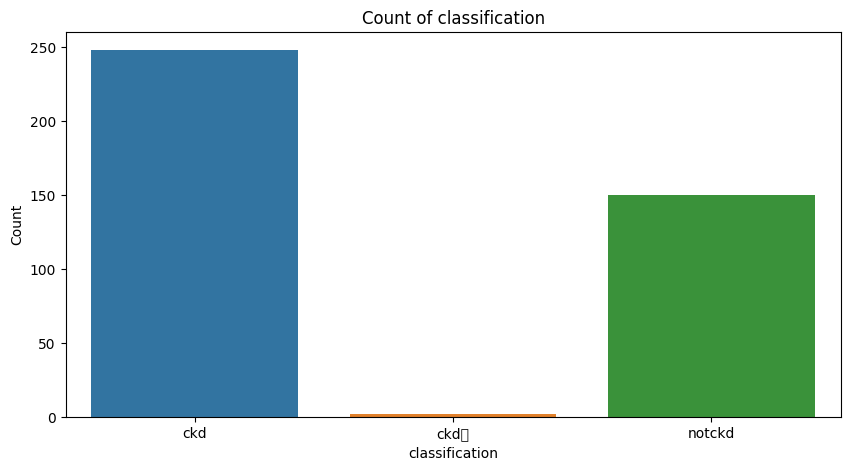

In [17]:
plt.figure(figsize=(5, 20))
num_plots = len(string_cols)

for column in string_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.title(f'Count of {column}')

    # Save the figure as an image file (e.g., PNG)
    plt.savefig(f'{column}_count_plot.png')

plt.show()

From above graph, we haave identified abnormal values in some non-numeric columns that require correction.

Based on a review of relevant studies, I have identified key risk factors for Chronic Kidney Disease, including diabetes mellitus, hypertension, advanced age, sex, and ethnicity. However, this dataset only contains information on diabetes mellitus, hypertension, and age. To further explore these relationships, I will create plots to visualize their respective associations with the 'classification'

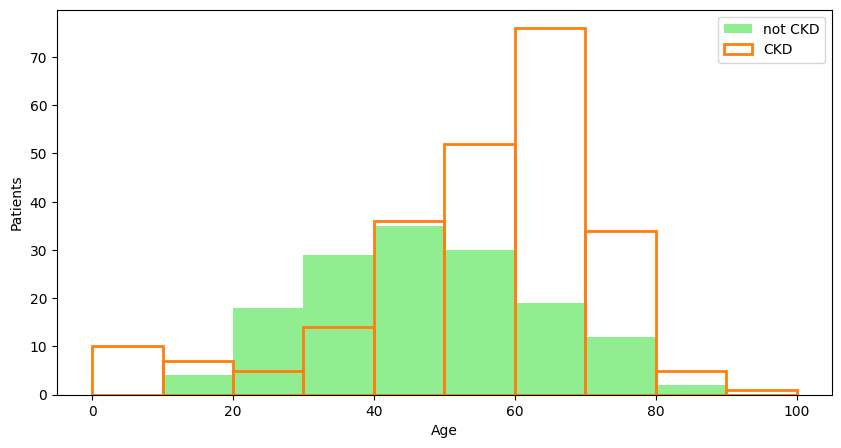

In [18]:
bins_age = [0,10,20,30,40,50,60,70,80,90,100]

fig, ax = plt.subplots(1, 1, figsize=(10,5))
ax.hist(df.loc[df['classification']=='notckd'].age,bins=bins_age,color='lightgreen',label='not CKD')
ax.hist(df.loc[df['classification']=='ckd'].age,bins=bins_age,facecolor='none',edgecolor='tab:orange',linewidth=2,label='CKD')
ax.set_xlabel('Age')
ax.set_ylabel('Patients')
ax.legend()
plt.savefig('hist_CKDbyAge')
plt.show()

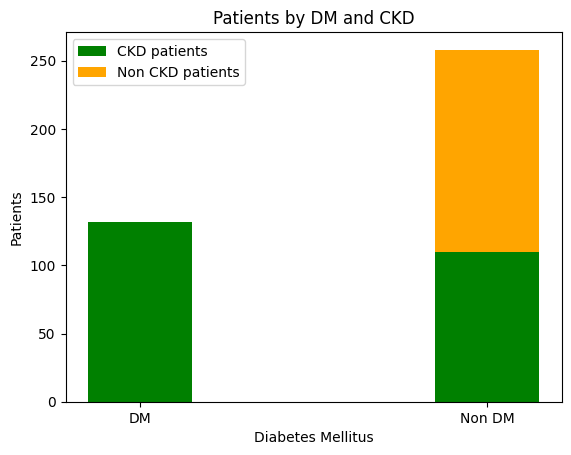

In [19]:
# Calculate counts
dm_ckd = sum((df['dm'] == 'yes') & (df['classification'] == 'ckd'))
notdm_ckd = sum((df['dm'] == 'no') & (df['classification'] == 'ckd'))
dm_notckd = sum((df['dm'] == 'yes') & (df['classification'] == 'notckd'))
notdm_notckd = sum((df['dm'] == 'no') & (df['classification'] == 'notckd'))

labels_dm = ['DM', 'Non DM']
labels_ckd = [dm_ckd, notdm_ckd]
labels_notckd = [dm_notckd, notdm_notckd]

# Make the plot
fig, ax = plt.subplots(1, 1)
width = 0.3

ax.bar(labels_dm, labels_ckd, width, label='CKD patients', color='green')
ax.bar(labels_dm, labels_notckd, width, bottom=labels_ckd, label='Non CKD patients', color='orange')

ax.set_xlabel('Diabetes Mellitus')
ax.set_ylabel('Patients')
ax.set_title('Patients by DM and CKD')
ax.legend()

plt.savefig("bar_ckd_dm")

plt.show()

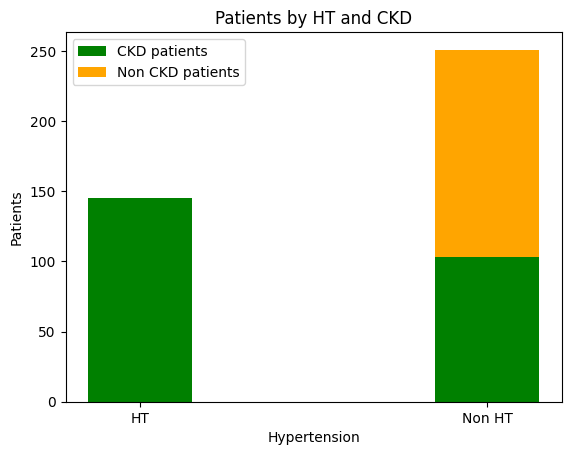

In [20]:
# Calculate counts
htn_ckd = sum((df['htn'] == 'yes') & (df['classification'] == 'ckd'))
nothtn_ckd = sum((df['htn'] == 'no') & (df['classification'] == 'ckd'))
htn_notckd = sum((df['htn'] == 'yes') & (df['classification'] == 'notckd'))
nothtn_notckd = sum((df['htn'] == 'no') & (df['classification'] == 'notckd'))

labels_ht = ['HT', 'Non HT']
labels_ht_ckd = [htn_ckd, nothtn_ckd]
labels_ht_notckd = [htn_notckd, nothtn_notckd]

# Make the plot
fig, ax = plt.subplots(1, 1)
width = 0.3

ax.bar(labels_ht, labels_ht_ckd, width, label='CKD patients', color='green')
ax.bar(labels_ht, labels_ht_notckd, width, bottom=labels_ht_ckd, label='Non CKD patients', color='orange')

ax.set_xlabel('Hypertension')
ax.set_ylabel('Patients')
ax.set_title('Patients by HT and CKD')
ax.legend()
plt.savefig("bar_ckd_ht")
plt.show()


# Cleaning data

Before running our data through our machine learning algorithm we must clean it: we need to decide what to do with abnormal value and missing data (i.e. NaNs) and convert categorical variables to numbers.

## Abnormal value

In [21]:
#replace abnormal values
replace_t = {'\t':np.nan,'\t?':np.nan,'\t43':'43','\t6200':'6200','\t8400':'8400',' yes':'yes','\tyes':'yes','\tno':'no','ckd\t':'ckd'}
_ = [print(col, df[string_cols].replace(replace_t)[col].unique()) for col in df[string_cols].replace(replace_t)]

sg [1.02  1.01  1.005 1.015   nan 1.025]
al [ 1.  4.  2.  3.  0. nan  5.]
su [ 0.  3.  4.  1. nan  2.  5.]
rbc [nan 'normal' 'abnormal']
pc ['normal' 'abnormal' nan]
pcc ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
htn ['yes' 'no' nan]
dm ['yes' 'no' nan]
cad ['no' 'yes' nan]
appet ['good' 'poor' nan]
pe ['no' 'yes' nan]
ane ['no' 'yes' nan]
classification ['ckd' 'notckd']


In [22]:
df = df.replace(replace_t)

## Remove outlier

In [23]:
# Calculate the interquartile range (IQR) for each column
Q1_sc = df['sc'].quantile(0.25)
Q3_sc = df['sc'].quantile(0.75)
iqr_sc = Q3_sc - Q1_sc

Q1_sod = df['sod'].quantile(0.25)
Q3_sod = df['sod'].quantile(0.75)
iqr_sod = Q3_sod - Q1_sod

Q1_pot = df['pot'].quantile(0.25)
Q3_pot = df['pot'].quantile(0.75)
iqr_pot = Q3_pot - Q1_pot

# Calculate means after removing outliers for each column
meansc_without_outliers = df['sc'][(df['sc'] > (Q1_sc - 1.5 * iqr_sc)) & (df['sc'] < (Q3_sc + 1.5 * iqr_sc))].mean()
meansod_without_outliers = df['sod'][(df['sod'] > (Q1_sod - 1.5 * iqr_sod)) & (df['sod'] < (Q3_sod + 1.5 * iqr_sod))].mean()
meanpot_without_outliers = df['pot'][(df['pot'] > (Q1_pot - 1.5 * iqr_pot)) & (df['pot'] < (Q3_pot + 1.5 * iqr_pot))].mean()

# Impute outliers with the mean
df['sc'] = df['sc'].apply(lambda x: meansc_without_outliers if (x < Q1_sc - 1.5 * iqr_sc or x > Q3_sc + 1.5 * iqr_sc) else x)
df['sod'] = df['sod'].apply(lambda x: meansod_without_outliers if (x < Q1_sod - 1.5 * iqr_sod or x > Q3_sod + 1.5 * iqr_sod) else x)
df['pot'] = df['pot'].apply(lambda x: meanpot_without_outliers if (x < Q1_pot - 1.5 * iqr_pot or x > Q3_pot + 1.5 * iqr_pot) else x)

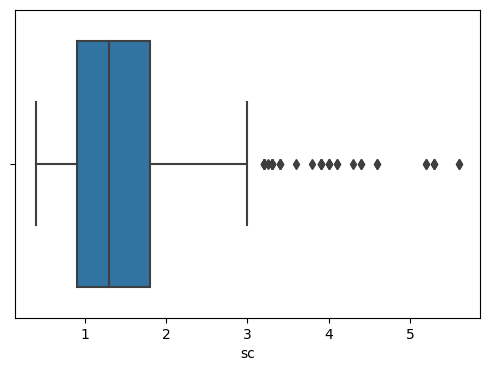

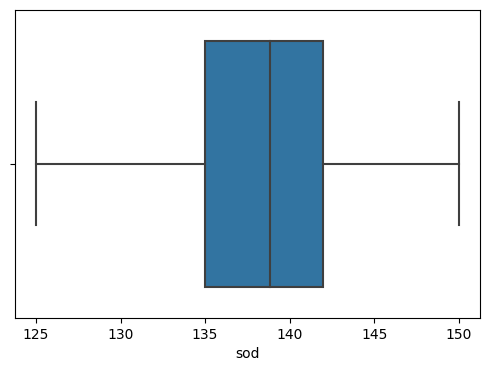

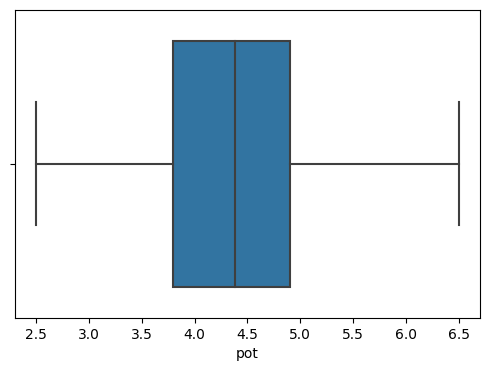

In [24]:
outlier = ['sc','sod','pot']

for column in outlier:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=column)

    plt.show()

## Missing data

In [25]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

We will replace each NaN entry in the dataframe with the mean for continuous variables or the mode for categorical variables.

In [26]:
from sklearn.impute import SimpleImputer

impute_mode = SimpleImputer(missing_values=np.nan,strategy="most_frequent")
impute_mean = SimpleImputer(missing_values=np.nan,strategy="mean")

In [27]:
df[string_cols]=pd.DataFrame(impute_mode.fit_transform(df[string_cols]))

In [28]:
df[numeric_cols]=pd.DataFrame(impute_mean.fit_transform(df[numeric_cols]))

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    float64
 2   bp              400 non-null    float64
 3   sg              400 non-null    object 
 4   al              400 non-null    object 
 5   su              400 non-null    object 
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    float64
 11  bu              400 non-null    float64
 12  sc              400 non-null    float64
 13  sod             400 non-null    float64
 14  pot             400 non-null    float64
 15  hemo            400 non-null    float64
 16  pcv             400 non-null    float64
 17  wc              400 non-null    flo

## Scale data

the continuous variables are not on the same scale. I will standardize the scale of these variables.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

df_scale=pd.concat([df.drop(numeric_cols, axis=1), scaled_X], axis=1)[df.columns]
df_scale

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,-0.205464,0.262338,1.02,1.0,0.0,normal,normal,notpresent,notpresent,...,0.628372,-0.240519,5.869015e-01,yes,yes,no,good,no,no,ckd
1,1,-2.623810,-1.966580,1.02,4.0,0.0,normal,normal,notpresent,notpresent,...,-0.108649,-0.954786,-1.058283e-15,no,no,no,good,no,no,ckd
2,2,0.620313,0.262338,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,-0.968506,-0.359563,-1.058283e-15,no,yes,no,poor,no,yes,ckd
3,3,-0.205464,-0.480635,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,-0.845669,-0.677016,-9.620758e-01,yes,no,no,poor,yes,yes,ckd
4,4,-0.028511,0.262338,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,-0.477159,-0.438926,-1.280111e-01,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,0.207425,0.262338,1.02,0.0,0.0,normal,normal,notpresent,notpresent,...,0.996882,-0.677016,2.294455e-01,no,no,no,good,no,no,notckd
396,396,-0.559368,-0.480635,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,1.856739,-0.240519,1.778423e+00,no,no,no,good,no,no,notckd
397,397,-2.328890,0.262338,1.02,0.0,0.0,normal,normal,notpresent,notpresent,...,1.242555,-0.716697,8.252061e-01,no,no,no,good,no,no,notckd
398,398,-2.033969,-1.223607,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,1.488229,-0.478608,1.420967e+00,no,no,no,good,no,no,notckd


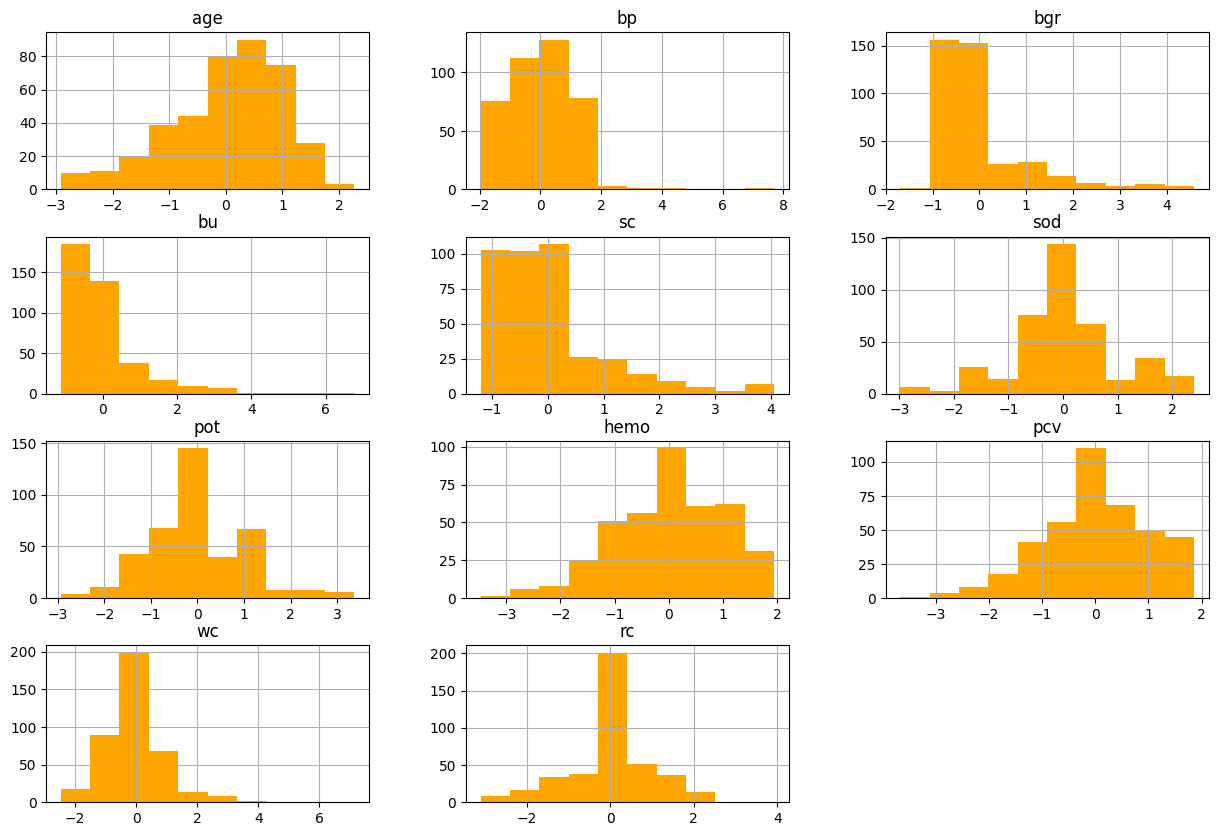

In [31]:
df_scale[numeric_cols].hist(figsize=(15,10),color = 'orange')
plt.savefig('The distribution of scaled numerical attributes.jpg')
plt.show()

## Encoding

In [32]:
cat = {'normal':1,'abnormal':0,'present':1,'notpresent':0,'yes':1,'no':0,'good':1,'poor':0,'ckd':1,'notckd':0}
df = df_scale.applymap(lambda x: cat.get(x, x))

# Save file for train model

In [33]:
#drop id columns because it is not essential.
df.drop('id',axis=1,inplace=True)

In [34]:
data = df.to_csv('clean_data.csv',index = False)